# 03. Global calibration

Are Kalshi prices calibrated, horizon by horizon and family by family?

Tools, as fixed in the protocol:

- reliability diagrams with 10 price bins;
- Brier score with its Murphy decomposition, and the Brier Skill Score;
- the calibration regression logit P(o = 1) = α + β logit(p). Perfect calibration: α = 0 and β = 1. β > 1 means prices sit too close to 50% (favorite-longshot bias);
- 95% confidence intervals from a bootstrap resampling whole events (2,000 draws).

**Provisional results**: validation sample of 10 events per series.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmcal.calibration import murphy, calibration_regression, cluster_bootstrap, plot_reliability

N_BOOT = int(os.environ.get("N_BOOT", 2000))  # protocol: 2,000 draws
MIN_VOLUME = 10_000
HORIZON_ORDER = ["1h", "1d", "7d", "30d"]

obs = pd.read_parquet(ROOT / "data" / "observations.parquet")
obs = obs[obs["volume_before"] >= MIN_VOLUME]
print(f"{len(obs):,} observations in {obs['event_ticker'].nunique():,} events")

def stats(d):
    alpha, beta = calibration_regression(d["price"], d["outcome"])
    m = murphy(d["price"], d["outcome"])
    return {"alpha": alpha, "beta": beta, "BS": m["BS"], "REL": m["REL"], "RES": m["RES"], "UNC": m["UNC"], "BSS": m["BSS"]}

def with_ci(d, label):
    ci = cluster_bootstrap(d, stats, "event_ticker", n_boot=N_BOOT)
    row = {"group": label, "n_obs": len(d), "n_events": d["event_ticker"].nunique()}
    for stat in ci.index:
        row[stat] = ci.loc[stat, "estimate"]
        row[stat + "_lo"], row[stat + "_hi"] = ci.loc[stat, "ci_low"], ci.loc[stat, "ci_high"]
    return row

def fmt(v, lo, hi, d=2):
    return f"{v:.{d}f} [{lo:.{d}f}, {hi:.{d}f}]"
print(f"Bootstrap draws: {N_BOOT:,}")

12,970 observations in 1,979 events
Bootstrap draws: 2,000


## 1. All families pooled, by horizon

Pooling mixes families with very different sample sizes (sports and weather dominate), so this is only a first look. Section 3 separates the families.

In [2]:
pooled = pd.DataFrame([with_ci(obs[obs["horizon"] == h], h) for h in HORIZON_ORDER if (obs["horizon"] == h).any()])
table = pd.DataFrame({
    "horizon": pooled["group"], "obs": pooled["n_obs"], "events": pooled["n_events"],
    "beta [95% CI]": [fmt(r.beta, r.beta_lo, r.beta_hi) for r in pooled.itertuples()],
    "alpha [95% CI]": [fmt(r.alpha, r.alpha_lo, r.alpha_hi) for r in pooled.itertuples()],
    "BSS [95% CI]": [fmt(r.BSS, r.BSS_lo, r.BSS_hi) for r in pooled.itertuples()],
})
table

,horizon,obs,events,beta [95% CI],alpha [95% CI],BSS [95% CI]
0,1h,6935,1596,"1.29 [1.21, 1.39]","-0.23 [-0.43, -0.02]","0.86 [0.84, 0.88]"
1,1d,3803,978,"1.07 [0.98, 1.18]","-0.10 [-0.24, 0.06]","0.62 [0.58, 0.66]"
2,7d,1591,370,"1.08 [0.97, 1.22]","-0.29 [-0.56, -0.03]","0.63 [0.57, 0.67]"
3,30d,641,156,"1.07 [0.92, 1.30]","-0.30 [-0.65, 0.07]","0.64 [0.55, 0.71]"


## 2. Murphy decomposition by horizon

BS = REL - RES + UNC. REL measures miscalibration (lower is better), RES measures discrimination (higher is better), UNC depends only on the sample.

In [3]:
pooled.set_index("group")[["BS", "REL", "RES", "UNC"]].round(4)

,BS,REL,RES,UNC
group,,,,
1h,0.0313,0.0006,0.1942,0.2249
1d,0.0873,0.0002,0.1426,0.2298
7d,0.0890,0.0014,0.1499,0.2376
30d,0.0807,0.0038,0.1465,0.2239


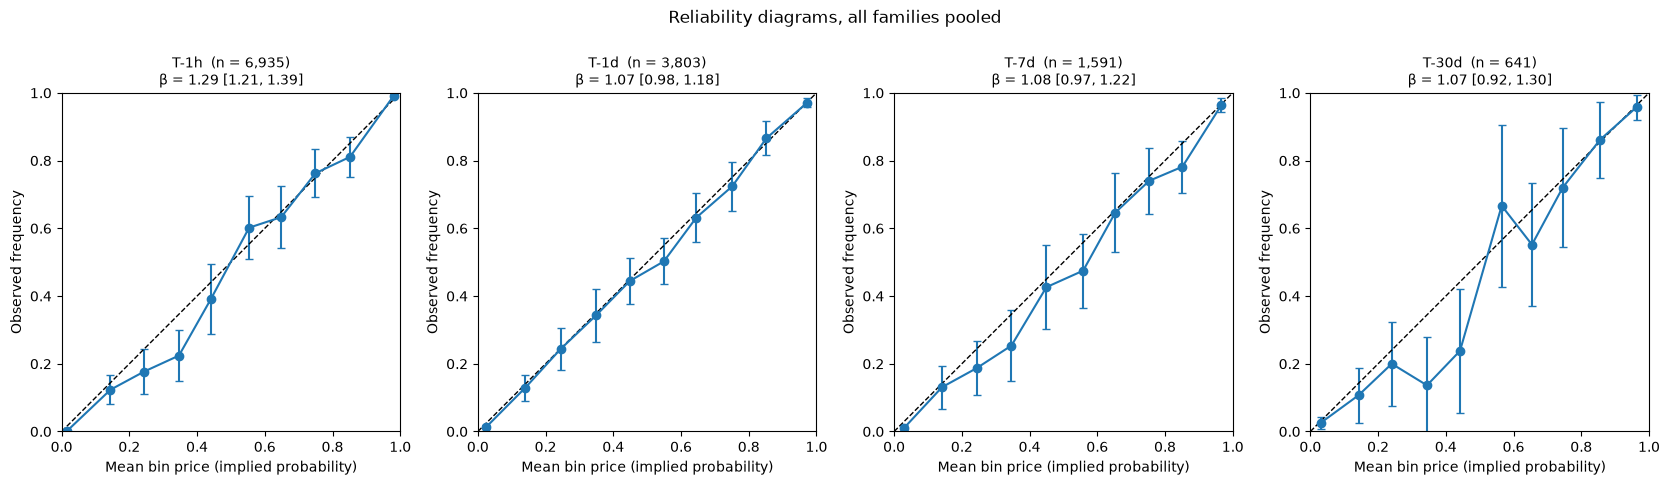

In [4]:
hs = [h for h in HORIZON_ORDER if (obs["horizon"] == h).any()]
fig, axes = plt.subplots(1, len(hs), figsize=(4.2 * len(hs), 4.6))
for ax, h in zip(axes, hs):
    d = obs[obs["horizon"] == h]
    plot_reliability(ax, d["price"], d["outcome"])
    r = pooled.set_index("group").loc[h]
    ax.set_title(f"T-{h}  (n = {len(d):,})\nβ = {fmt(r.beta, r.beta_lo, r.beta_hi)}", fontsize=10)
    ax.get_legend() and ax.get_legend().remove()
fig.suptitle("Reliability diagrams, all families pooled", y=1.02)
plt.tight_layout()
fig.savefig(ROOT / "figures" / "reliability_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. By family

Each family is shown at the horizons the protocol allows for it. Groups with fewer than 100 observations or 20 events are reported but should not be interpreted.

In [5]:
rows = []
for (fam, h), d in obs.groupby(["family", "horizon"]):
    rows.append({"family": fam, "horizon": h, **with_ci(d, f"{fam} {h}")})
by_fam = pd.DataFrame(rows)
by_fam["horizon"] = pd.Categorical(by_fam["horizon"], HORIZON_ORDER, ordered=True)
by_fam = by_fam.sort_values(["family", "horizon"])
by_fam["reliable"] = (by_fam["n_obs"] >= 100) & (by_fam["n_events"] >= 20)
pd.DataFrame({
    "family": by_fam["family"], "horizon": by_fam["horizon"],
    "obs": by_fam["n_obs"], "events": by_fam["n_events"],
    "beta [95% CI]": [fmt(r.beta, r.beta_lo, r.beta_hi) for r in by_fam.itertuples()],
    "BSS": by_fam["BSS"].round(2), "REL": by_fam["REL"].round(4),
    "interpretable": by_fam["reliable"],
}).reset_index(drop=True)

,family,horizon,obs,events,beta [95% CI],BSS,REL,interpretable
0,crypto,1h,15,5,"nan [nan, nan]",0.74,0.0164,False
1,crypto,1d,6,1,"nan [nan, nan]",NaN,0.0002,False
2,crypto,7d,4,1,"nan [nan, nan]",NaN,0.0100,False
3,crypto,30d,5,1,"nan [nan, nan]",NaN,0.0662,False
4,culture,1h,1310,234,"1.29 [1.12, 1.59]",0.92,0.0010,True
5,culture,1d,1109,200,"1.17 [0.97, 1.52]",0.83,0.0020,True
6,culture,7d,372,60,"1.13 [0.91, 1.47]",0.59,0.0060,True
7,culture,30d,174,23,"0.89 [0.69, 1.19]",0.45,0.0096,True
8,economics,1h,2971,519,"1.21 [1.10, 1.34]",0.74,0.0010,True
9,economics,1d,1807,345,"1.03 [0.94, 1.16]",0.65,0.0009,True


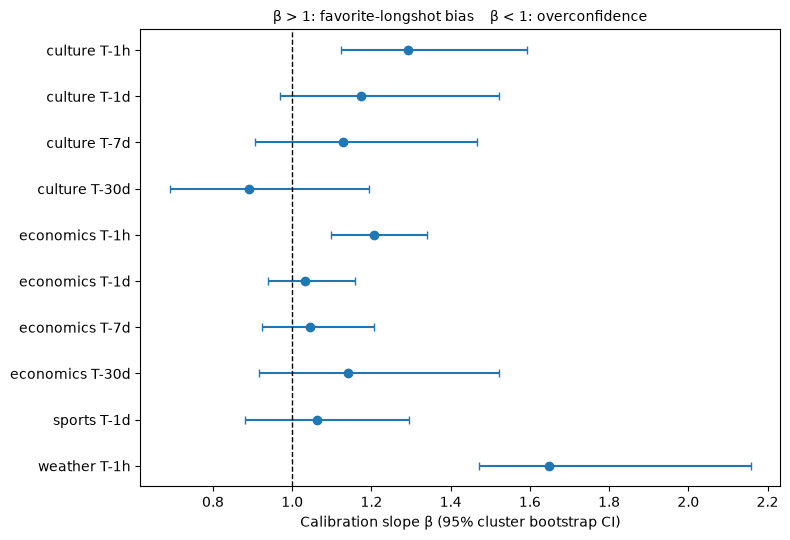

In [6]:
d = by_fam[by_fam["reliable"]]
fig, ax = plt.subplots(figsize=(8, 0.45 * len(d) + 1))
y = np.arange(len(d))
ax.errorbar(d["beta"], y, xerr=[d["beta"] - d["beta_lo"], d["beta_hi"] - d["beta"]], fmt="o", capsize=3)
ax.axvline(1, color="k", ls="--", lw=1)
ax.set_yticks(y, [f"{r.family} T-{r.horizon}" for r in d.itertuples()])
ax.invert_yaxis()
ax.set_xlabel("Calibration slope β (95% cluster bootstrap CI)")
ax.set_title("β > 1: favorite-longshot bias    β < 1: overconfidence", fontsize=10)
plt.tight_layout()
fig.savefig(ROOT / "figures" / "beta_by_family.png", dpi=150)
plt.show()

## 4. Export

The tables are saved for the write-up.

In [7]:
pooled.to_csv(ROOT / "data" / "results_calibration_pooled.csv", index=False)
by_fam.to_csv(ROOT / "data" / "results_calibration_by_family.csv", index=False)
print("Saved")

Saved
